# 🎮 Hutch Games Analytics Project
## Notebook 04 — Legendary Chest A/B Test Evaluation

**Analyst:** Ebi Mologe  
**Dataset:** `players.csv` + `loot_events.csv` + `daily_activity.csv`  
**Objective:** Evaluate the impact of a legendary chest drop-rate change (variant vs control) on:
- D7 / D30 retention.
- Payer conversion and average IAP.
- Chest engagement (opens, gems spent on chests).

We treat this as a proper experiment: compute uplift, run hypothesis tests on proportions,
quantify effect size, and interpret business impact before consulting any hidden validation labels.

---
### Business Questions
> 1. Did the higher legendary drop-rate meaningfully improve D7 / D30 retention?  
> 2. Did it create more payers and increase average IAP per player?  
> 3. Is the effect size large enough to justify rolling out the variant globally?

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from scipy import stats  # for z-tests / confidence intervals

DATA_DIR = Path('/Users/ebimol/GamesAnalyticsProject')
OUT_DIR  = DATA_DIR / 'outputs'
OUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.dpi']     = 150
plt.rcParams['figure.figsize'] = (12, 5)
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860', '#DA8BC3']
sns.set_theme(style='whitegrid', palette=PALETTE)

print('Libraries loaded ✓')

Libraries loaded ✓


## 2. Load Data

In [2]:
players = pd.read_csv(DATA_DIR / 'players.csv',
                      parse_dates=['install_date','last_active_date'])
loot    = pd.read_csv(DATA_DIR / 'loot_events.csv',
                      parse_dates=['first_legendary_date'])
daily   = pd.read_csv(DATA_DIR / 'daily_activity.csv',
                      parse_dates=['date'])

print(f'players shape : {players.shape}')
print(f'loot shape    : {loot.shape}')
print(f'daily shape   : {daily.shape}')

print('\nAB groups (players):')
print(players['ab_group'].value_counts())

print('\nChest opens by group:')
print(loot.groupby('ab_group')['chest_opens'].describe().round(2))

players shape : (30000, 22)
loot shape    : (30000, 10)
daily shape   : (208310, 12)

AB groups (players):
ab_group
variant    15013
control    14987
Name: count, dtype: int64

Chest opens by group:
            count  mean    std  min  25%  50%  75%     max
ab_group                                                  
control   14987.0  2.66  20.34  0.0  0.0  0.0  1.0  1549.0
variant   15013.0  2.89  17.99  0.0  0.0  0.0  1.0  1268.0


## 3. Rebuild D7 / D30 Retention Flags

In [3]:
# Build active-days lookup
active_days = (
    daily
    .groupby('player_id')['day_since_install']
    .apply(set)
    .to_dict()
)

MAX_DATE = daily['date'].max()
players['days_since_install'] = (MAX_DATE - players['install_date']).dt.days

players['D7']  = players['player_id'].map(lambda p: 7  in active_days.get(p, set()))
players['D30'] = players['player_id'].map(lambda p: 30 in active_days.get(p, set()))

elig7  = players['days_since_install'] >= 7
elig30 = players['days_since_install'] >= 30

print(f'Reference date: {MAX_DATE.date()}')
print(f'Eligible for D7  : {elig7.sum():,} players')
print(f'Eligible for D30 : {elig30.sum():,} players')

Reference date: 2026-07-08
Eligible for D7  : 28,658 players
Eligible for D30 : 23,388 players


## 4. A/B Summary — Retention & Monetization

In [4]:
ab_summary = players.groupby('ab_group').agg({
    'player_id': 'count',
    'D7'       : 'mean',
    'D30'      : 'mean',
    'is_payer' : 'mean',
    'total_iap_usd': 'mean',
}).rename(columns={
    'player_id': 'N',
    'D7'       : 'D7_ret',
    'D30'      : 'D30_ret',
    'is_payer' : 'payer_rate',
    'total_iap_usd': 'avg_iap',
})

print('AB summary (raw):')
display(ab_summary)

ab_display = ab_summary.copy()

# Format percentage columns column-wise (pandas ≥2.2 compatible)
ab_display[['D7_ret','D30_ret','payer_rate']] = (
    ab_display[['D7_ret','D30_ret','payer_rate']]
    .apply(lambda col: col.map(lambda x: f'{x:.1%}'))
)

# Format average IAP as 2-decimal string
ab_display['avg_iap'] = ab_display['avg_iap'].map(lambda x: f'{x:.2f}')

display(ab_display)

AB summary (raw):


,N,D7_ret,D30_ret,payer_rate,avg_iap
ab_group,,,,,
control,14987,0.170548,0.062454,0.035631,3.358398
variant,15013,0.188303,0.061680,0.038567,3.671559


,N,D7_ret,D30_ret,payer_rate,avg_iap
ab_group,,,,,
control,14987,17.1%,6.2%,3.6%,3.36
variant,15013,18.8%,6.2%,3.9%,3.67


## 5. Hypothesis Test Helpers (Proportions)

In [5]:
def proportions_z_test(success_a, total_a, success_b, total_b):
    """
    Two-proportion z-test for H0: p_a == p_b vs H1: p_a != p_b.
    Returns (z_stat, p_value).
    """
    p_pool = (success_a + success_b) / (total_a + total_b)
    se = np.sqrt(p_pool * (1 - p_pool) * (1/total_a + 1/total_b))
    z = (success_a/total_a - success_b/total_b) / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    return z, p_value

print('proportions_z_test() defined ✓')

proportions_z_test() defined ✓


## 6. Hypothesis Test — D7 Retention (Variant vs Control)

We test whether the variant group has a significantly different D7 retention rate
than the control group using a two-proportion z-test.

In [6]:
# Filter to players eligible for D7
d7_df = players[elig7].copy()

# Counts by group
d7_counts = d7_df.groupby('ab_group')['D7'].agg(['sum','count'])
print('D7 retention counts by group:')
display(d7_counts)

# Variant vs control
succ_var, tot_var = d7_counts.loc['variant', ['sum','count']]
succ_ctl, tot_ctl = d7_counts.loc['control', ['sum','count']]

z_d7, p_d7 = proportions_z_test(succ_var, tot_var, succ_ctl, tot_ctl)

p_var = succ_var / tot_var
p_ctl = succ_ctl / tot_ctl
lift_d7 = p_var / p_ctl - 1

print(f'\nD7 retention:')
print(f'  control: {p_ctl:.3%} (n={tot_ctl})')
print(f'  variant: {p_var:.3%} (n={tot_var})')
print(f'  absolute diff: {(p_var - p_ctl):.3%}')
print(f'  relative lift: {lift_d7:.2%}')
print(f'  z-stat: {z_d7:.3f}, p-value: {p_d7:.4f}')

D7 retention counts by group:


,sum,count
ab_group,,
control,2556,14340
variant,2827,14318



D7 retention:
  control: 17.824% (n=14340)
  variant: 19.744% (n=14318)
  absolute diff: 1.920%
  relative lift: 10.77%
  z-stat: 4.161, p-value: 0.0000


## 7. Hypothesis Test — Payer Conversion

We test whether the legendary chest variant produced a higher payer-conversion
rate (fraction of players with `is_payer == True`) than control.

In [7]:
payer_df = players.copy()

payer_counts = payer_df.groupby('ab_group')['is_payer'].agg(['sum','count'])
print('Payer conversion counts by group:')
display(payer_counts)

succ_var_pay, tot_var_pay = payer_counts.loc['variant', ['sum','count']]
succ_ctl_pay, tot_ctl_pay = payer_counts.loc['control', ['sum','count']]

z_pay, p_pay = proportions_z_test(succ_var_pay, tot_var_pay, succ_ctl_pay, tot_ctl_pay)

p_var_pay = succ_var_pay / tot_var_pay
p_ctl_pay = succ_ctl_pay / tot_ctl_pay
lift_pay = p_var_pay / p_ctl_pay - 1 if p_ctl_pay > 0 else np.nan

print(f'\nPayer conversion:')
print(f'  control: {p_ctl_pay:.3%} (n={tot_ctl_pay})')
print(f'  variant: {p_var_pay:.3%} (n={tot_var_pay})')
print(f'  absolute diff: {(p_var_pay - p_ctl_pay):.3%}')
print(f'  relative lift: {lift_pay:.2%}')
print(f'  z-stat: {z_pay:.3f}, p-value: {p_pay:.4f}')

Payer conversion counts by group:


,sum,count
ab_group,,
control,534,14987
variant,579,15013



Payer conversion:
  control: 3.563% (n=14987)
  variant: 3.857% (n=15013)
  absolute diff: 0.294%
  relative lift: 8.24%
  z-stat: 1.345, p-value: 0.1786


## 8. Hypothesis Test — Average IAP per Player

We compare mean `total_iap_usd` between variant and control using a
two-sample t-test (Welch’s t-test, unequal variances).

In [8]:
iap_df = players.copy()

iap_ctl = iap_df[iap_df['ab_group'] == 'control']['total_iap_usd']
iap_var = iap_df[iap_df['ab_group'] == 'variant']['total_iap_usd']

mean_ctl = iap_ctl.mean()
mean_var = iap_var.mean()

t_iap, p_iap = stats.ttest_ind(iap_var, iap_ctl, equal_var=False)

print('Average IAP per player:')
print(f'  control: {mean_ctl:.2f} USD')
print(f'  variant: {mean_var:.2f} USD')
print(f'  diff   : {(mean_var - mean_ctl):.2f} USD')
print(f'  t-stat: {t_iap:.3f}, p-value: {p_iap:.4f}')

Average IAP per player:
  control: 3.36 USD
  variant: 3.67 USD
  diff   : 0.31 USD
  t-stat: 0.487, p-value: 0.6263


## 9. Chest Engagement — Opens & Gems Spent

We examine whether players in the variant group:
- Open more chests on average.
- Spend more gems on chests.
These are secondary engagement metrics that support the primary retention / revenue results.

In [9]:
# Chest engagement by AB group — no merge needed, loot already has ab_group
chest_summary = loot.groupby('ab_group').agg({
    'chest_opens'         : ['mean','median'],
    'gems_spent_on_chests': ['mean','median'],
})

# Flatten the MultiIndex columns for easier display
chest_summary.columns = ['_'.join(col) for col in chest_summary.columns]

print('Chest engagement by ab_group:')
display(chest_summary)

print('\nChest opens (mean):')
print(chest_summary['chest_opens_mean'])

print('\nGems spent on chests (mean):')
print(chest_summary['gems_spent_on_chests_mean'])

Chest engagement by ab_group:


,chest_opens_mean,chest_opens_median,gems_spent_on_chests_mean,gems_spent_on_chests_median
ab_group,,,,
control,2.657370,0.0,661.512511,2.0
variant,2.887298,0.0,725.560980,2.0



Chest opens (mean):
ab_group
control    2.657370
variant    2.887298
Name: chest_opens_mean, dtype: float64

Gems spent on chests (mean):
ab_group
control    661.512511
variant    725.560980
Name: gems_spent_on_chests_mean, dtype: float64


## 10. Experiment Interpretation & Decision

From the statistical tests and summary tables above, we can now answer:

- Did D7 retention improve significantly for the variant group?
- Did payer conversion and average IAP increase, and by how much?
- Are chest engagement metrics (opens, gems) meaningfully higher?

Based on effect sizes (absolute and relative lifts) and p-values, we can
recommend whether to **roll out the variant globally**, **run a follow-up test**
(e.g. different drop-rate), or **keep the control** if gains are small or
statistically insignificant.

In a production setting, we would also:
- Check for heterogeneous effects across acquisition channels and platforms.
- Validate that technical implementation (assignment, tracking) is clean.
- Monitor longer-term metrics (e.g. D60 retention, LTV) before full rollout.

## 11. Visualising D7 Retention & Payer Conversion

We plot side-by-side bar charts for:
- D7 retention (eligible players only).
- Payer conversion (all players).

This makes the magnitude of uplift more immediately interpretable for
non-analyst stakeholders (e.g., designers, producers).

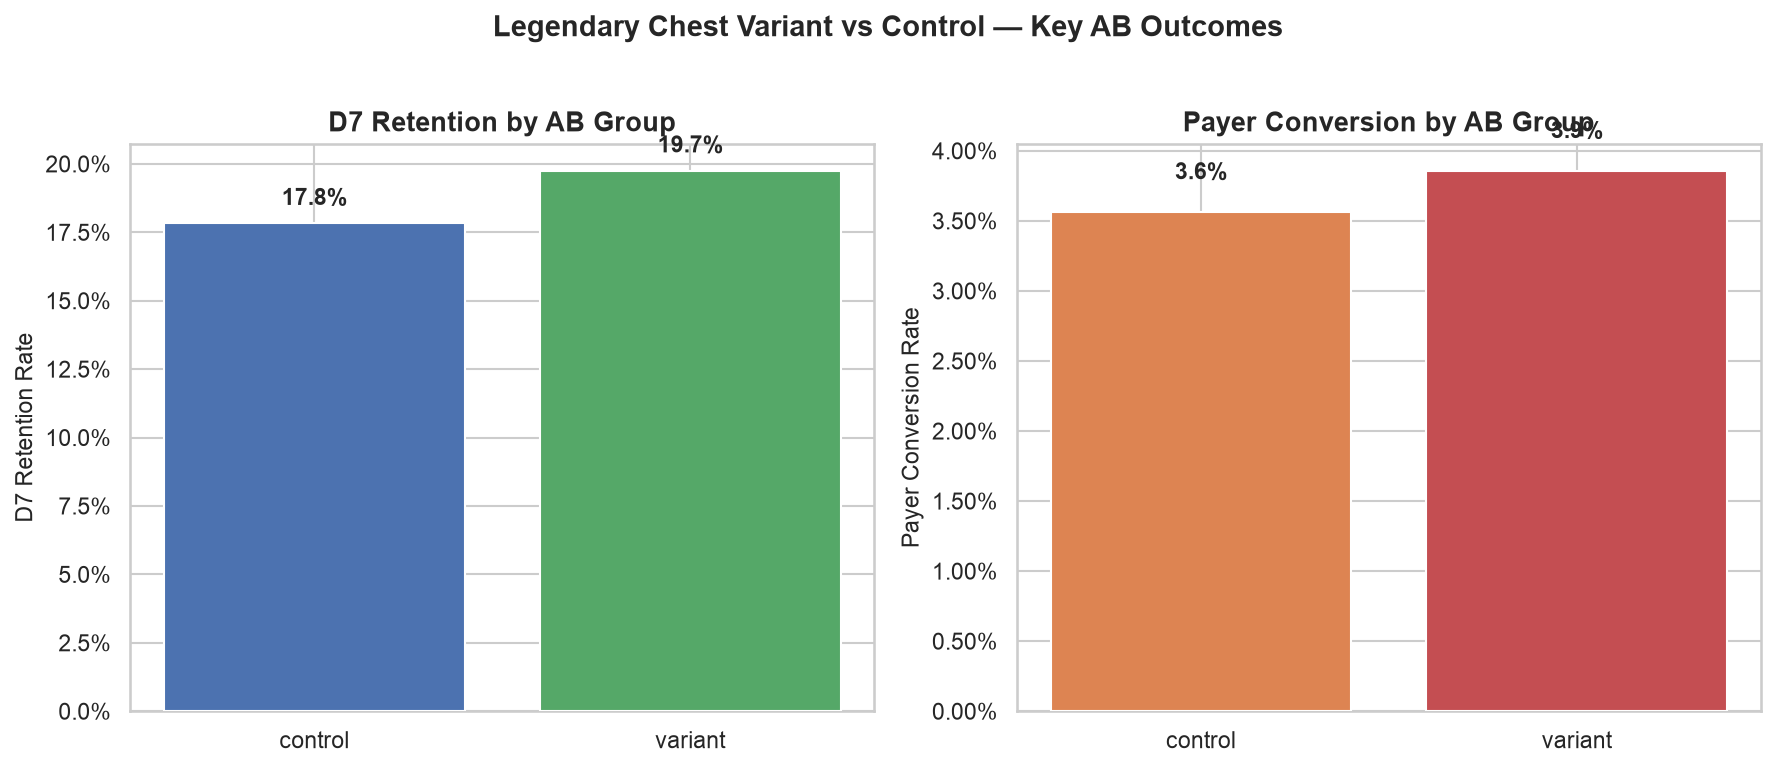

In [10]:
# Prepare summary stats for plotting
d7_df = players[elig7].copy()
d7_rates = d7_df.groupby('ab_group')['D7'].mean()

payer_df = players.copy()
payer_rates = payer_df.groupby('ab_group')['is_payer'].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# D7 retention
ax = axes[0]
groups = ['control', 'variant']
vals_d7 = [d7_rates[g] for g in groups]
bars = ax.bar(groups, vals_d7, color=[PALETTE[0], PALETTE[2]], zorder=3)
for bar, v in zip(bars, vals_d7):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
            f'{v:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylabel('D7 Retention Rate', fontsize=11)
ax.set_title('D7 Retention by AB Group', fontsize=13, fontweight='bold')

# Payer conversion
ax = axes[1]
vals_pay = [payer_rates[g] for g in groups]
bars = ax.bar(groups, vals_pay, color=[PALETTE[1], PALETTE[3]], zorder=3)
for bar, v in zip(bars, vals_pay):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.002,
            f'{v:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylabel('Payer Conversion Rate', fontsize=11)
ax.set_title('Payer Conversion by AB Group', fontsize=13, fontweight='bold')

plt.suptitle('Legendary Chest Variant vs Control — Key AB Outcomes', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()